In [1]:
import scarf

scarf.set_verbosity('WARNING')

scarf.fetch_dataset(
    'tenx_5K_pbmc_rnaseq',
    save_path='scarf_datasets',
    as_zarr=True,
)
ds = scarf.DataStore(
    'scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    nthreads=4,
    min_features_per_cell=10,
)
ds

DataStore has 3940 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_tSNE2', 
            'RNA_tSNE1', 'RNA_percentRibo', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_UMAP2', 
            'RNA_cluster', 'RNA_leiden_cluster', 'RNA_UMAP1'
   RNA assay has 13632 (33538) features and following metadata:
            'I', 'ids', 'names', 'I__hvgs', 'nCells', 
            'dropOuts'

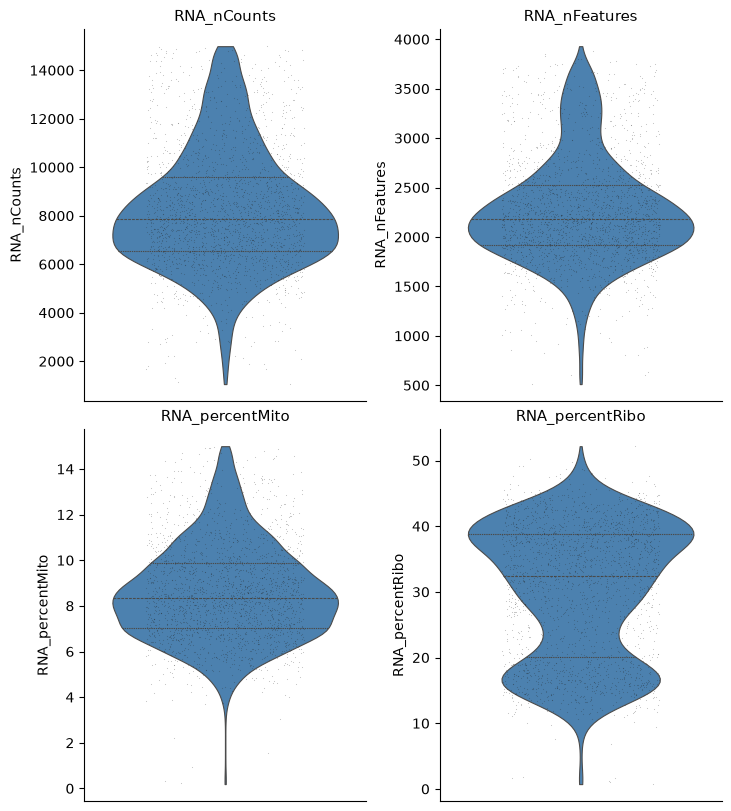

PlotResult(axes=4, tables=4, legends=1, scales=0, owns_figure=True, rendered=True)

In [2]:
qc_cols = [
    c for c in (
        'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo'
    )
    if c in ds.cells.columns
]
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
)

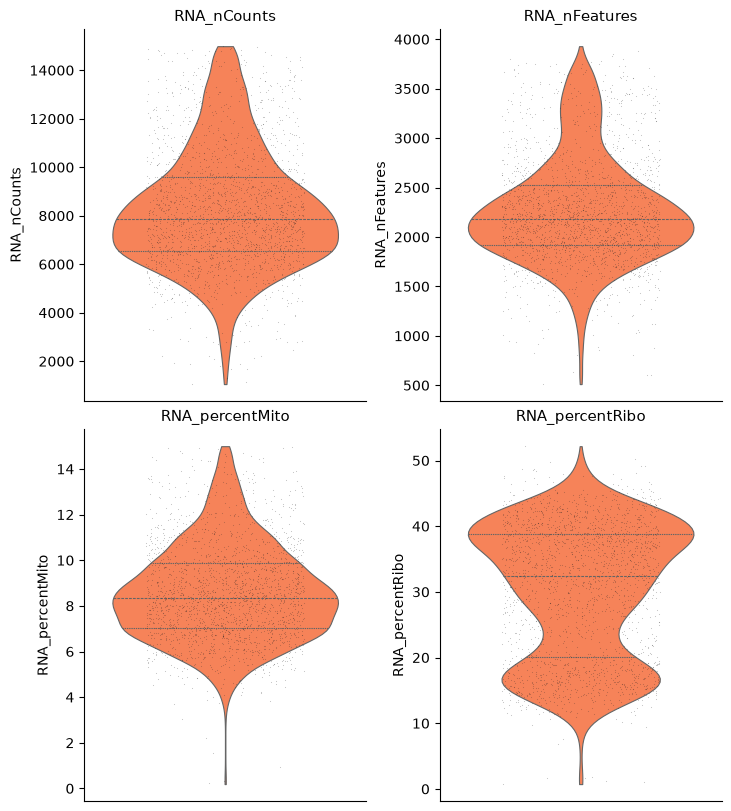

PlotResult(axes=4, tables=4, legends=1, scales=0, owns_figure=True, rendered=True)

In [3]:
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
    color='coral',
)

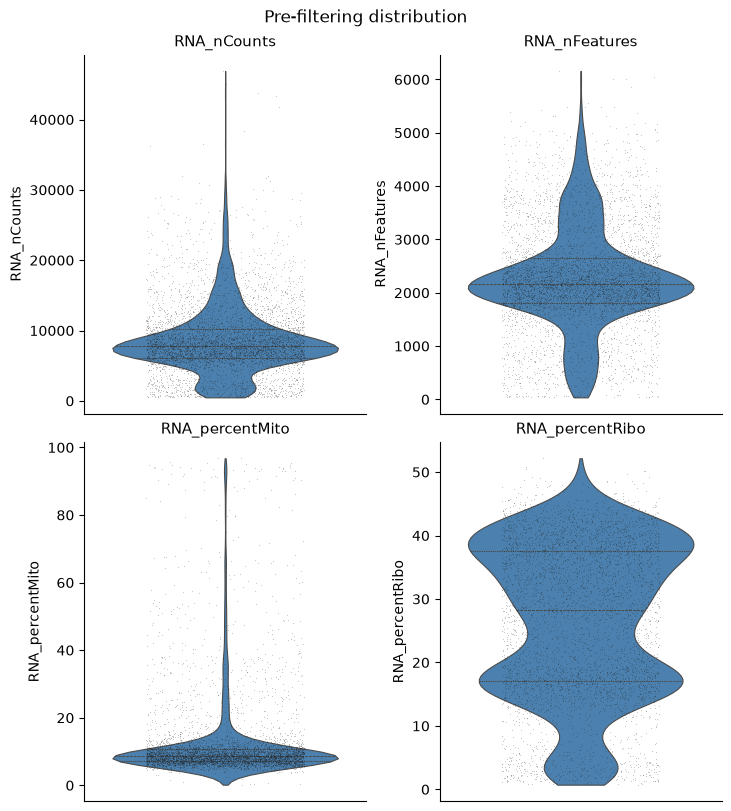

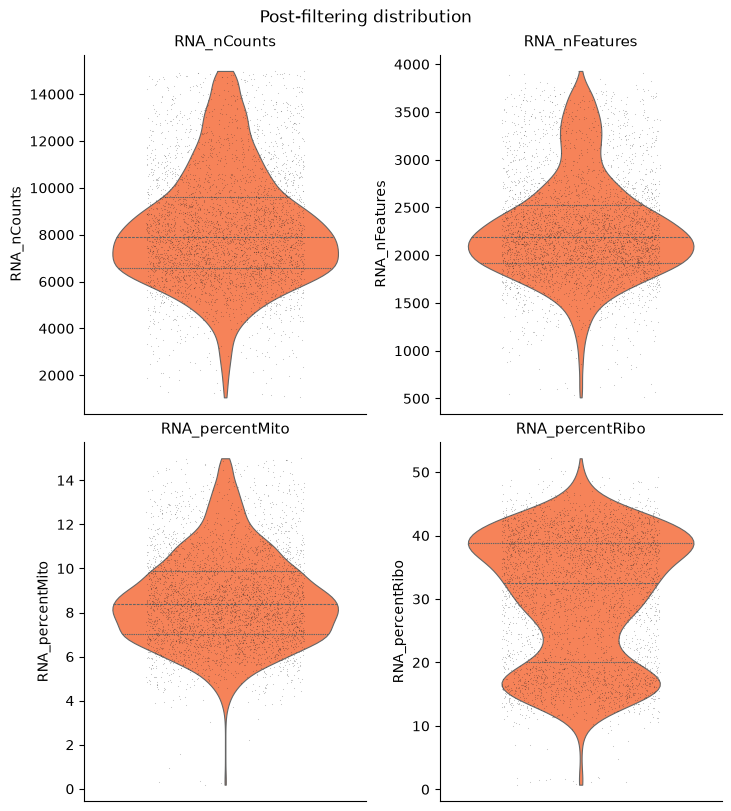

In [4]:
ds.auto_filter_cells(show_qc_plots=True)

In [5]:
ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
ds.make_graph(feat_key='hvgs', k=11, dims=15, n_centroids=100)
ds.run_leiden_clustering(resolution=0.5)
score_col = ds.run_doublet_detection(cluster_key='RNA_leiden_cluster')
ds.run_umap(n_epochs=100, spread=5, min_dist=1, parallel=True)

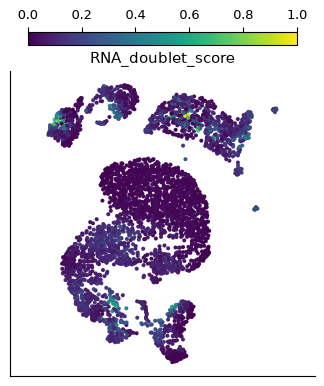

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [6]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=score_col,
)

In [7]:
ds.cells.to_pandas_dataframe(columns=[score_col], key='I').describe()

,RNA_doublet_score
count,3940.000000
mean,0.081811
std,0.099350
min,0.000000
25%,0.015048
50%,0.052282
75%,0.114982
max,1.000000
